# Hybrid ARIMA + Random Forest Expense Forecasting — Training Pipeline

Trains a per-category ARIMA model to generate short-horizon expense forecasts,
then feeds those forecasts as features into a tuned `RandomForestRegressor`
that predicts `monthly_expense` for every `(user_id, expense_category)` pair.

**Split policy:** strictly chronological (time-based). No random shuffling is
used anywhere in the train/test split or in cross-validation for
hyperparameter tuning.

Requires `hybrid_utils.py` to be present in the same folder as this notebook.

## 1. Imports

In [13]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from hybrid_utils import clean_arima_forecast

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports OK")

Imports OK


## Configuration

In [14]:
# ------------------------------------------------------------------
# File paths -- adjust if your files live in a different folder
# ------------------------------------------------------------------
DATA_DIR = "."
USERS_FILE = os.path.join(DATA_DIR, "users.xlsx")
EXPENSES_FILE = os.path.join(DATA_DIR, "monthly_expenses.xlsx")
CALENDAR_FILE = os.path.join(DATA_DIR, "calendar_events.xlsx")
ARTIFACT_PATH = os.path.join(DATA_DIR, "hybrid_artifacts.pkl")

# ------------------------------------------------------------------
# Expense taxonomy
# ------------------------------------------------------------------
EXPENSE_CATEGORIES = [
    "Food", "Cafe", "Taxi", "Public_Transport", "Shopping", "Entertainment",
    "Health", "Education", "Rent", "Utilities", "Travel", "Gifts",
    "Insurance", "Investments", "Miscellaneous",
]

# ------------------------------------------------------------------
# ARIMA configuration
# ------------------------------------------------------------------
ARIMA_ORDER = (1, 1, 1)
ARIMA_MIN_HISTORY = 12       # minimum months of history required to fit ARIMA
ARIMA_FORECAST_STEPS = 3
ARIMA_LOWER_BAND = 0.30      # forecast below 30% of last observed value -> fallback
ARIMA_UPPER_BAND = 2.50      # forecast above 250% of last observed value -> fallback

# ------------------------------------------------------------------
# Chronological split configuration
# ------------------------------------------------------------------
TEST_MONTHS = 3              # most recent N months held out as the test set

# ------------------------------------------------------------------
# Calendar-event configuration
# ------------------------------------------------------------------
EVENT_CATEGORY_MAP = {
    "Birthday": ["Food", "Entertainment", "Shopping"],
    "Wedding": ["Food", "Shopping", "Travel", "Gifts"],
    "Anniversary": ["Food", "Gifts"],
    "Festival": ["Shopping", "Food", "Gifts"],
    "Vacation": ["Travel", "Food", "Entertainment"],
    "Conference": ["Travel", "Food"],
    "Business Trip": ["Travel", "Food"],
    "Insurance Renewal": ["Insurance"],
    "Medical Appointment": ["Health"],
    "College Fee": ["Education"],
    "School Fee": ["Education"],
    "EMI Due": ["Miscellaneous"],
    "Rent Due": ["Rent"],
    "Car Service": ["Miscellaneous"],
    "Laptop Purchase": ["Miscellaneous"],
    "Mobile Purchase": ["Miscellaneous"],
    "Baby Shower": ["Gifts", "Shopping", "Food"],
    "Housewarming": ["Shopping", "Food", "Gifts"],
    "Exam": ["Education"],
    "Graduation": ["Gifts", "Food", "Shopping"],
    "Parents Visit": ["Food"],
    "Family Function": ["Food", "Gifts", "Shopping"],
    "Vehicle Purchase": ["Miscellaneous"],
    "Subscription Renewal": ["Entertainment", "Miscellaneous"],
}
DEFAULT_EVENT_CATEGORIES = ["Miscellaneous"]
RECURRING_EVENT_TYPES = {
    "Birthday", "Anniversary", "Insurance Renewal", "Festival",
    "Rent Due", "Subscription Renewal", "EMI Due",
}
IMPORTANCE_RANK = {"Low": 1, "Medium": 2, "High": 3}
IMPORTANCE_WEIGHT = {"Low": 0.5, "Medium": 1.0, "High": 1.5}
CALENDAR_TRAILING_WINDOW = 6   # months used for the causal spending baseline

# ------------------------------------------------------------------
# Feature / target configuration
# ------------------------------------------------------------------
CATEGORICAL_FEATURE_COLS = [
    "user_id", "expense_category", "gender", "occupation", "city",
    "marital_status", "financial_personality",
    "upcoming_event_type", "event_importance_level",
]

FEATURE_COLS = [
    "user_id", "expense_category", "time_idx", "monthly_income", "year", "month",
    "age", "gender", "occupation", "city", "marital_status", "family_size",
    "financial_personality", "event_count", "calendar_pressure", "planning_months_avg",
    "upcoming_event_type", "event_importance_level",
    "arima_month_1", "arima_month_2", "arima_month_3",
]

TARGET_COL = "monthly_expense"

# ------------------------------------------------------------------
# Random Forest tuning grid (kept small so the search finishes in
# reasonable time -- widen if you have compute to spare)
# ------------------------------------------------------------------
RF_PARAM_GRID = {
    "n_estimators": [200, 300],
    "max_depth": [12, 20],
    "min_samples_leaf": [1, 2],
}

print("Configuration loaded")

Configuration loaded


## 2. Dataset Loading

In [15]:
def load_raw_data(users_path, expenses_path, calendar_path):
    """Load the three raw source files used by the training pipeline."""
    users_raw = pd.read_excel(users_path)
    expenses_raw = pd.read_excel(expenses_path)
    calendar_raw = pd.read_excel(calendar_path)
    return users_raw, expenses_raw, calendar_raw


users_raw, expenses_raw, calendar_raw = load_raw_data(USERS_FILE, EXPENSES_FILE, CALENDAR_FILE)

print(f"users    : {users_raw.shape}")
print(f"expenses : {expenses_raw.shape}")
print(f"calendar : {calendar_raw.shape}")

users    : (1000, 10)
expenses : (24000, 21)
calendar : (12781, 8)


## 3. Data Cleaning — Build the Expense Panel

In [16]:
def build_expense_panel(expenses_df, users_df, categories):
    """
    Melt wide monthly expense data (one column per category) into a dense
    long panel with one row per (user_id, expense_category, time_idx),
    filling any implicit gaps with zero spend and forward/backward-filled
    demographics.
    """
    demo_cols = [
        "user_id", "age", "gender", "occupation", "city",
        "marital_status", "family_size", "financial_personality",
    ]
    users = users_df[demo_cols].copy()

    long_df = expenses_df.melt(
        id_vars=["user_id", "year", "month", "income"],
        value_vars=categories,
        var_name="expense_category",
        value_name="monthly_expense",
    ).rename(columns={"income": "monthly_income"})

    base_year = long_df["year"].min()
    long_df["time_idx"] = (long_df["year"] - base_year) * 12 + (long_df["month"] - 1)

    all_users = long_df["user_id"].unique()
    all_time_idx = range(long_df["time_idx"].min(), long_df["time_idx"].max() + 1)
    full_index = pd.MultiIndex.from_product(
        [all_users, categories, all_time_idx],
        names=["user_id", "expense_category", "time_idx"],
    )
    panel = pd.DataFrame(index=full_index).reset_index()

    panel = panel.merge(
        long_df[["user_id", "expense_category", "time_idx", "monthly_expense", "monthly_income"]],
        on=["user_id", "expense_category", "time_idx"],
        how="left",
    )
    panel["monthly_expense"] = panel["monthly_expense"].fillna(0.0)

    # ------------------------------------------------------------------
    # Data-integrity guard: monthly_expense is the RF training target.
    # Unlike the ARIMA forecast pipeline (see clean_arima_forecast in
    # hybrid_utils.py), nothing downstream ever screened this raw column
    # for negative values (refunds / correction rows / data-entry errors
    # in monthly_expenses.xlsx). A RandomForestRegressor can only ever
    # predict a negative number if at least one negative value made it
    # into y_train, so any negative raw expense here would silently
    # propagate all the way to inference-time predictions. Clip and
    # report it explicitly, the same way ARIMA forecasts are sanitized.
    n_negative = int((panel["monthly_expense"] < 0).sum())
    if n_negative > 0:
        print(
            f"WARNING: {n_negative} raw monthly_expense rows were negative "
            f"(refunds/corrections/data-entry errors) and have been clipped "
            f"to 0.0 so they cannot leak into the Random Forest target."
        )
        panel["monthly_expense"] = panel["monthly_expense"].clip(lower=0.0)

    panel["year"] = base_year + panel["time_idx"] // 12
    panel["month"] = panel["time_idx"] % 12 + 1
    panel["monthly_income"] = (
        panel.groupby("user_id")["monthly_income"].transform(lambda s: s.ffill().bfill())
    )

    panel = panel.merge(users, on="user_id", how="left")
    demo_feature_cols = demo_cols[1:]
    panel[demo_feature_cols] = (
        panel.groupby("user_id")[demo_feature_cols].transform(lambda s: s.ffill().bfill())
    )

    panel = panel.sort_values(["user_id", "expense_category", "time_idx"]).reset_index(drop=True)

    if panel.isna().sum().sum() != 0:
        raise ValueError("Unexpected missing values remain after panel construction")

    assert (panel["monthly_expense"] >= 0).all(), "Negative values remain in monthly_expense target"

    return panel, base_year


panel_df, BASE_YEAR = build_expense_panel(expenses_raw, users_raw, EXPENSE_CATEGORIES)

print(f"Panel shape : {panel_df.shape}")
print(f"Base year   : {BASE_YEAR}")
panel_df.head()

Panel shape : (360000, 14)
Base year   : 2024


,user_id,expense_category,time_idx,monthly_expense,monthly_income,year,month,age,gender,occupation,city,marital_status,family_size,financial_personality
0,U00001,Cafe,0,634.82,29407.38,2024,1,24,Male,Driver,Chennai,Single,1,Traveller
1,U00001,Cafe,1,583.23,29480.89,2024,2,24,Male,Driver,Chennai,Single,1,Traveller
2,U00001,Cafe,2,711.74,29554.60,2024,3,24,Male,Driver,Chennai,Single,1,Traveller
3,U00001,Cafe,3,573.77,32386.86,2024,4,24,Male,Driver,Chennai,Single,1,Traveller
4,U00001,Cafe,4,653.82,32467.82,2024,5,24,Male,Driver,Chennai,Single,1,Traveller


## Calendar Feature Engineering\n\n(Required for the `event_count`, `calendar_pressure`, `planning_months_avg`, `upcoming_event_type`, and `event_importance_level` features used in Step 8.)

In [17]:
def explode_events_by_category(calendar_df, event_category_map, default_categories, id_suffix=""):
    """Duplicate each calendar event once per expense category it touches."""
    rows = []
    for row in calendar_df.itertuples(index=False):
        categories_touched = event_category_map.get(row.event_type, default_categories)
        for category in categories_touched:
            rows.append((
                f"{row.event_id}{id_suffix}", row.user_id, row.event_date, row.event_title,
                row.event_type, row.importance, row.estimated_total_cost,
                row.planning_months, category,
            ))
    return pd.DataFrame(rows, columns=[
        "event_id", "user_id", "event_date", "event_title", "event_type",
        "importance", "estimated_total_cost", "planning_months", "expense_category",
    ])


def build_calendar_long(calendar_df, event_category_map, default_categories, recurring_event_types):
    """
    Expand historical events by category, and additionally project
    recurring event types one year forward so future-dated recurring
    events (birthdays, rent, insurance, etc.) also contribute features.
    """
    calendar_df = calendar_df.copy()
    calendar_df["event_date"] = pd.to_datetime(calendar_df["event_date"])

    historical = explode_events_by_category(calendar_df, event_category_map, default_categories)

    recurring = calendar_df[calendar_df["event_type"].isin(recurring_event_types)].copy()
    recurring["event_date"] = recurring["event_date"] + pd.DateOffset(years=1)
    projected = explode_events_by_category(
        recurring, event_category_map, default_categories, id_suffix="_proj"
    )

    calendar_long = pd.concat([historical, projected], ignore_index=True)
    calendar_long["year"] = calendar_long["event_date"].dt.year
    calendar_long["month"] = calendar_long["event_date"].dt.month
    return calendar_long


def aggregate_calendar_features(calendar_long, importance_rank, importance_weight):
    """Collapse exploded events into one row per (user, category, year, month)."""
    calendar_long = calendar_long.copy()
    calendar_long["importance_rank"] = calendar_long["importance"].map(importance_rank).fillna(1)

    agg = calendar_long.groupby(["user_id", "expense_category", "year", "month"]).agg(
        event_count=("event_id", "count"),
        total_estimated_cost=("estimated_total_cost", "sum"),
        planning_months_avg=("planning_months", "mean"),
    ).reset_index()

    dominant_idx = calendar_long.groupby(
        ["user_id", "expense_category", "year", "month"]
    )["estimated_total_cost"].idxmax()
    dominant = calendar_long.loc[
        dominant_idx, ["user_id", "expense_category", "year", "month", "event_type", "importance"]
    ].rename(columns={"event_type": "upcoming_event_type", "importance": "event_importance_level"})

    agg = agg.merge(dominant, on=["user_id", "expense_category", "year", "month"], how="left")
    agg["importance_weight"] = agg["event_importance_level"].map(importance_weight).fillna(0.5)

    return agg


calendar_long_df = build_calendar_long(
    calendar_raw, EVENT_CATEGORY_MAP, DEFAULT_EVENT_CATEGORIES, RECURRING_EVENT_TYPES
)
calendar_agg_df = aggregate_calendar_features(calendar_long_df, IMPORTANCE_RANK, IMPORTANCE_WEIGHT)

print(f"Exploded calendar rows   : {calendar_long_df.shape}")
print(f"Aggregated calendar rows : {calendar_agg_df.shape}")
calendar_agg_df.head()

Exploded calendar rows   : (30895, 11)
Aggregated calendar rows : (28359, 10)


,user_id,expense_category,year,month,event_count,total_estimated_cost,planning_months_avg,upcoming_event_type,event_importance_level,importance_weight
0,U00001,Education,2025,4,1,1490.02,1.0,Exam,Medium,1.0
1,U00001,Education,2025,10,1,13823.73,2.0,College Fee,High,1.5
2,U00001,Entertainment,2025,11,1,13342.41,3.0,Vacation,Medium,1.0
3,U00001,Food,2024,1,1,5996.05,1.0,Housewarming,Low,0.5
4,U00001,Food,2024,6,1,2590.09,6.0,Graduation,High,1.5


In [18]:
def attach_calendar_features(panel, calendar_agg, trailing_window):
    """
    Merge calendar-derived features onto the expense panel.

    `calendar_pressure` is normalized by a CAUSAL trailing spending
    baseline (a rolling average shifted by one period), so the feature
    never uses information from the row's own or future months --
    this keeps it leakage-free with respect to the chronological split
    performed later.
    """
    panel = panel.sort_values(["user_id", "expense_category", "time_idx"]).copy()

    panel["trailing_avg_expense"] = (
        panel.groupby(["user_id", "expense_category"])["monthly_expense"]
        .transform(lambda s: s.rolling(window=trailing_window, min_periods=1).mean().shift(1))
        .fillna(0.0)
    )
    panel["hist_total"] = (
        panel.groupby(["user_id", "time_idx"])["trailing_avg_expense"]
        .transform("sum")
        .clip(lower=1.0)
    )

    merged = panel.merge(
        calendar_agg,
        on=["user_id", "expense_category", "year", "month"],
        how="left",
    )

    for col in ["event_count", "total_estimated_cost", "planning_months_avg", "importance_weight"]:
        merged[col] = merged[col].fillna(0.0)
    merged["upcoming_event_type"] = merged["upcoming_event_type"].fillna("None")
    merged["event_importance_level"] = merged["event_importance_level"].fillna("Low")

    merged["calendar_pressure"] = (
        merged["total_estimated_cost"] / merged["hist_total"]
    ) * merged["importance_weight"]

    merged = merged.drop(
        columns=["trailing_avg_expense", "hist_total", "total_estimated_cost", "importance_weight"]
    )

    if merged.isna().sum().sum() != 0:
        raise ValueError("Unexpected missing values remain after attaching calendar features")

    return merged


def cast_feature_dtypes(df):
    """Enforce consistent dtypes so downstream encoding/modeling is stable."""
    df = df.copy()
    categorical_cols = [
        "user_id", "expense_category", "gender", "occupation", "city",
        "marital_status", "financial_personality",
        "upcoming_event_type", "event_importance_level",
    ]
    numeric_cols = [
        "age", "family_size", "month", "year", "monthly_expense", "monthly_income",
        "event_count", "calendar_pressure", "planning_months_avg",
    ]
    for col in categorical_cols:
        df[col] = df[col].astype(str)
    for col in numeric_cols:
        df[col] = df[col].astype(float)
    df["time_idx"] = df["time_idx"].astype(int)
    return df


panel_df = attach_calendar_features(panel_df, calendar_agg_df, CALENDAR_TRAILING_WINDOW)
panel_df = cast_feature_dtypes(panel_df)

print(f"Panel shape after calendar features : {panel_df.shape}")
print(f"Missing values                      : {panel_df.isna().sum().sum()}")
panel_df.head()

Panel shape after calendar features : (360000, 19)
Missing values                      : 0


,user_id,expense_category,time_idx,monthly_expense,monthly_income,year,month,age,gender,occupation,city,marital_status,family_size,financial_personality,event_count,planning_months_avg,upcoming_event_type,event_importance_level,calendar_pressure
0,U00001,Cafe,0,634.82,29407.38,2024.0,1.0,24.0,Male,Driver,Chennai,Single,1.0,Traveller,0.0,0.0,None,Low,0.0
1,U00001,Cafe,1,583.23,29480.89,2024.0,2.0,24.0,Male,Driver,Chennai,Single,1.0,Traveller,0.0,0.0,None,Low,0.0
2,U00001,Cafe,2,711.74,29554.60,2024.0,3.0,24.0,Male,Driver,Chennai,Single,1.0,Traveller,0.0,0.0,None,Low,0.0
3,U00001,Cafe,3,573.77,32386.86,2024.0,4.0,24.0,Male,Driver,Chennai,Single,1.0,Traveller,0.0,0.0,None,Low,0.0
4,U00001,Cafe,4,653.82,32467.82,2024.0,5.0,24.0,Male,Driver,Chennai,Single,1.0,Traveller,0.0,0.0,None,Low,0.0


## 4. Chronological Train/Test Split\n\nSplit is purely a function of `time_idx` -- no shuffling, no random sampling.

In [19]:
def chronological_split(panel, test_months):
    """Hold out the most recent `test_months` months as the test set."""
    max_time_idx = panel["time_idx"].max()
    cutoff = max_time_idx - test_months + 1

    train_df = panel[panel["time_idx"] < cutoff].copy()
    test_df = panel[panel["time_idx"] >= cutoff].copy()

    if train_df.empty or test_df.empty:
        raise ValueError("Chronological split produced an empty train or test set")

    return train_df, test_df, cutoff


train_df, test_df, SPLIT_CUTOFF_TIME_IDX = chronological_split(panel_df, TEST_MONTHS)

print(f"Split cutoff time_idx : {SPLIT_CUTOFF_TIME_IDX}")
print(f"Train rows            : {train_df.shape[0]}  (time_idx range: {train_df['time_idx'].min()}-{train_df['time_idx'].max()})")
print(f"Test rows             : {test_df.shape[0]}  (time_idx range: {test_df['time_idx'].min()}-{test_df['time_idx'].max()})")

Split cutoff time_idx : 21
Train rows            : 315000  (time_idx range: 0-20)
Test rows             : 45000  (time_idx range: 21-23)


## 5. Train ARIMA Models (per user, per expense category)\n\nFit only on the **training** partition of each series, so the resulting forecast features carry no test-period leakage.

In [20]:
def train_arima_forecasts(train_panel, target_col, order, min_history, forecast_steps,
                           lower_band, upper_band):
    """
    Fit one ARIMA model per (user_id, expense_category) series using only
    the training-period history, and forecast the next `forecast_steps`
    months. Forecasts are guaranteed to be finite, non-negative, and
    stable (see `clean_arima_forecast`). Series with insufficient history
    or a failed fit fall back to repeating the last observed value.
    """
    records = []
    fitted_count, fallback_count = 0, 0

    groups = train_panel.sort_values("time_idx").groupby(["user_id", "expense_category"])

    for (user_id, category), group in tqdm(groups, desc="Training per-series ARIMA models"):
        series = group.sort_values("time_idx")[target_col].astype(float).values
        last_value = float(series[-1]) if len(series) else 0.0

        if len(series) < min_history:
            forecast = np.full(forecast_steps, last_value)
            fallback_count += 1
        else:
            try:
                model = ARIMA(series, order=order)
                fitted = model.fit()
                forecast = np.asarray(fitted.forecast(steps=forecast_steps), dtype=float)
                fitted_count += 1
            except Exception:
                forecast = np.full(forecast_steps, last_value)
                fallback_count += 1

        cleaned = clean_arima_forecast(forecast, last_value, lower_band, upper_band)

        records.append({
            "user_id": user_id,
            "expense_category": category,
            "arima_month_1": cleaned[0],
            "arima_month_2": cleaned[1],
            "arima_month_3": cleaned[2],
        })

    arima_df = pd.DataFrame.from_records(records)

    print(f"ARIMA models fit successfully : {fitted_count}")
    print(f"ARIMA fallback to last value  : {fallback_count}")
    print(f"Total (user, category) series : {len(arima_df)}")

    # Sanity checks required by the pipeline spec
    assert arima_df[["arima_month_1", "arima_month_2", "arima_month_3"]].isna().sum().sum() == 0, "NaNs in ARIMA output"
    assert np.isfinite(arima_df[["arima_month_1", "arima_month_2", "arima_month_3"]].values).all(), "Non-finite values in ARIMA output"
    assert (arima_df[["arima_month_1", "arima_month_2", "arima_month_3"]] >= 0).all().all(), "Negative values in ARIMA output"

    return arima_df


arima_forecasts_df = train_arima_forecasts(
    train_df, TARGET_COL, ARIMA_ORDER, ARIMA_MIN_HISTORY,
    ARIMA_FORECAST_STEPS, ARIMA_LOWER_BAND, ARIMA_UPPER_BAND,
)

arima_forecasts_df.head()

Training per-series ARIMA models: 100%|██████████| 15000/15000 [17:39<00:00, 14.16it/s]

ARIMA models fit successfully : 15000
ARIMA fallback to last value  : 0
Total (user, category) series : 15000


,user_id,expense_category,arima_month_1,arima_month_2,arima_month_3
0,U00001,Cafe,823.455436,819.685892,819.980051
1,U00001,Education,1689.276447,1686.992151,1687.068464
2,U00001,Entertainment,1195.830154,1197.556455,1197.912496
3,U00001,Food,5634.094768,5702.882861,5714.831108
4,U00001,Gifts,768.204758,875.364002,923.870202


## 6. Merge ARIMA Predictions (validated)

In [21]:
def merge_arima_features(df, arima_df):
    """
    Broadcast per-(user, expense_category) ARIMA forecasts onto every row
    of `df`. Validates that the join is many-to-one (no duplicated ARIMA
    rows), that every row receives a forecast (no missing merges), and
    that the row count is preserved (no incorrect / fan-out join).
    """
    duplicate_keys = arima_df.duplicated(subset=["user_id", "expense_category"]).sum()
    if duplicate_keys > 0:
        raise ValueError(f"ARIMA forecast table has {duplicate_keys} duplicated keys")

    before_rows = len(df)

    merged = df.merge(
        arima_df,
        on=["user_id", "expense_category"],
        how="left",
        validate="many_to_one",
    )

    if len(merged) != before_rows:
        raise ValueError("Row count changed during ARIMA merge -- indicates an incorrect join")

    forecast_cols = ["arima_month_1", "arima_month_2", "arima_month_3"]
    missing = merged[forecast_cols].isna().any(axis=1).sum()
    if missing > 0:
        raise ValueError(f"{missing} rows failed to receive an ARIMA forecast during merge")

    return merged


train_df = merge_arima_features(train_df, arima_forecasts_df)
test_df = merge_arima_features(test_df, arima_forecasts_df)

print("ARIMA merge validated for train_df and test_df")
print(f"train_df shape : {train_df.shape}")
print(f"test_df shape  : {test_df.shape}")

ARIMA merge validated for train_df and test_df
train_df shape : (315000, 22)
test_df shape  : (45000, 22)


## 7. Encode Categorical Columns

In [22]:
def fit_label_encoders(df, categorical_cols):
    """
    Fit one LabelEncoder per categorical identifier column.

    Fit on the full (train + test) set of *identifier* columns -- these
    are closed-vocabulary structural fields (user IDs, category names,
    city names, etc.), not statistics derived from the target, so this
    does not leak target information across the chronological split.
    """
    encoders = {}
    encoded_df = df.copy()
    for col in categorical_cols:
        encoder = LabelEncoder()
        encoded_df[col] = encoder.fit_transform(encoded_df[col].astype(str))
        encoders[col] = encoder
    return encoded_df, encoders


combined_df = pd.concat([train_df, test_df], axis=0, keys=["train", "test"])
combined_encoded, encoders = fit_label_encoders(combined_df, CATEGORICAL_FEATURE_COLS)

train_encoded = combined_encoded.xs("train").reset_index(drop=True)
test_encoded = combined_encoded.xs("test").reset_index(drop=True)

print("Encoders fit for:", list(encoders.keys()))
print(f"train_encoded shape : {train_encoded.shape}")
print(f"test_encoded shape  : {test_encoded.shape}")

Encoders fit for: ['user_id', 'expense_category', 'gender', 'occupation', 'city', 'marital_status', 'financial_personality', 'upcoming_event_type', 'event_importance_level']
train_encoded shape : (315000, 22)
test_encoded shape  : (45000, 22)


## 8. Train Random Forest (tuned)

In [23]:
def prepare_feature_matrix(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].astype(float).copy()
    return X, y


X_train, y_train = prepare_feature_matrix(train_encoded, FEATURE_COLS, TARGET_COL)
X_test, y_test = prepare_feature_matrix(test_encoded, FEATURE_COLS, TARGET_COL)

print(f"X_train : {X_train.shape}   X_test : {X_test.shape}")

X_train : (315000, 21)   X_test : (45000, 21)


In [24]:
def tune_random_forest(X_train, y_train, param_grid, n_splits=3, random_seed=RANDOM_SEED):
    """
    Hyperparameter search using TimeSeriesSplit cross-validation on
    time-sorted rows, so validation folds are always chronologically
    after their corresponding training folds -- no random CV shuffling.
    """
    sorted_idx = X_train.sort_values("time_idx").index
    X_sorted = X_train.loc[sorted_idx]
    y_sorted = y_train.loc[sorted_idx]

    time_series_cv = TimeSeriesSplit(n_splits=n_splits)
    base_model = RandomForestRegressor(random_state=random_seed, n_jobs=-1)

    search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=time_series_cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=False,
    )
    search.fit(X_sorted, y_sorted)

    print("Best cross-validated params :", search.best_params_)
    print(f"Best cross-validated MAE   : {-search.best_score_:.4f}")

    return search.best_params_


best_rf_params = tune_random_forest(X_train, y_train, RF_PARAM_GRID)

rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params)
rf_model.fit(X_train, y_train)

print("\nFinal Random Forest trained with params:", best_rf_params)

Best cross-validated params : {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}
Best cross-validated MAE   : 812.8604

Final Random Forest trained with params: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}


## 9. Evaluate

In [25]:
def evaluate_regression(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-6))) * 100
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(f"EVALUATION {label}".strip())
    print("=" * 60)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R2   : {r2:.4f}")

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}


y_pred_test = rf_model.predict(X_test)
test_metrics = evaluate_regression(y_test, y_pred_test, label="(Chronological Test Set)")

EVALUATION (Chronological Test Set)
MAE  : 1163.4133
RMSE : 3882.0619
MAPE : 16.65%
R2   : 0.9443


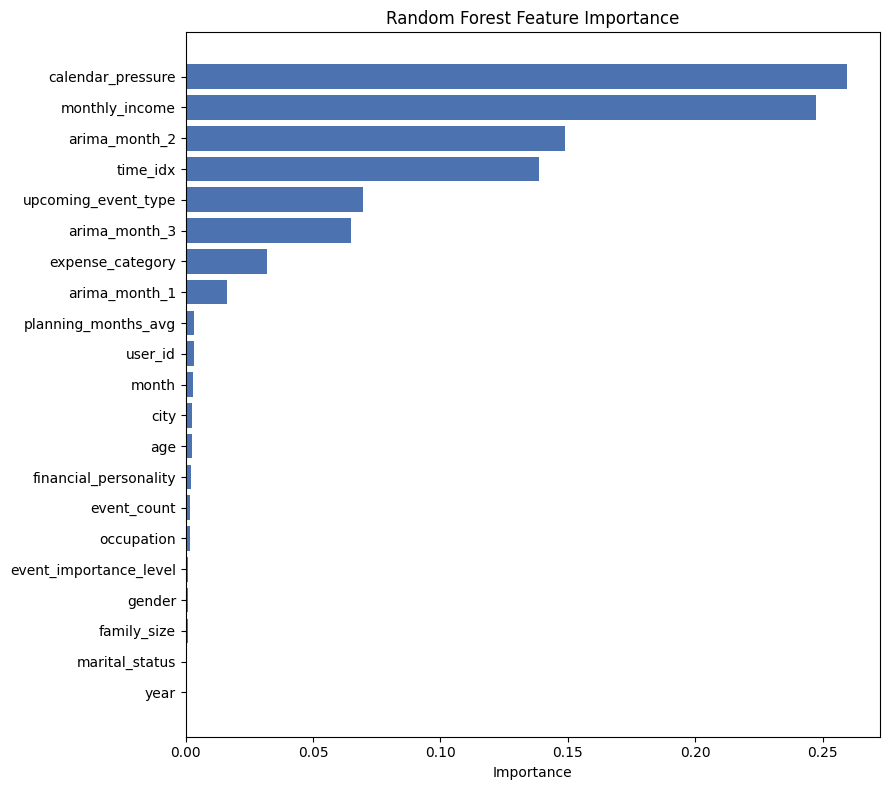

,feature,importance
0,calendar_pressure,0.259550
1,monthly_income,0.247422
2,arima_month_2,0.148915
3,time_idx,0.138822
4,upcoming_event_type,0.069570
5,arima_month_3,0.064822
6,expense_category,0.031896
7,arima_month_1,0.016112
8,planning_months_avg,0.003178
9,user_id,0.003068


In [26]:
def plot_feature_importance(model, feature_cols):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=True)

    plt.figure(figsize=(9, 8))
    plt.barh(importance_df["feature"], importance_df["importance"], color="#4C72B0")
    plt.xlabel("Importance")
    plt.title("Random Forest Feature Importance")
    plt.tight_layout()
    plt.show()

    return importance_df.sort_values("importance", ascending=False).reset_index(drop=True)


feature_importance_df = plot_feature_importance(rf_model, FEATURE_COLS)
feature_importance_df

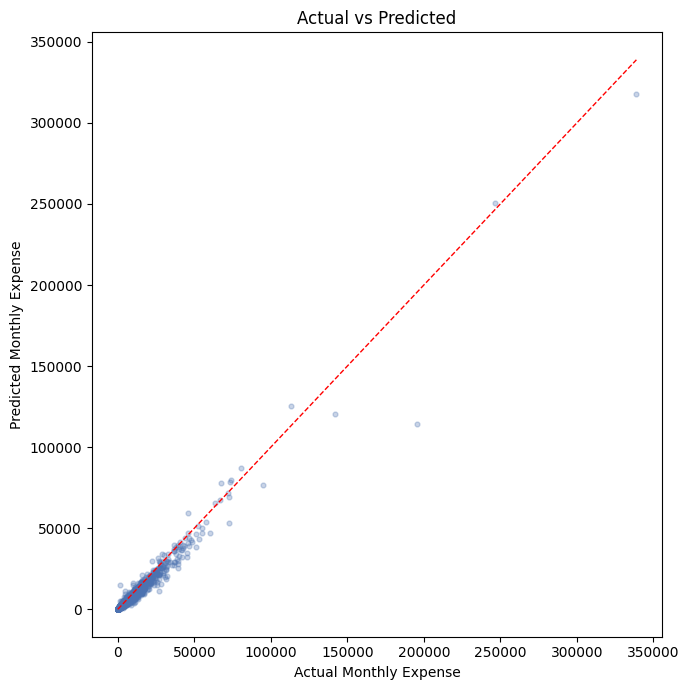

In [27]:
def plot_actual_vs_predicted(y_true, y_pred, sample_size=2000, random_seed=RANDOM_SEED):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    if len(y_true_arr) > sample_size:
        idx = np.random.RandomState(random_seed).choice(len(y_true_arr), sample_size, replace=False)
        y_true_arr, y_pred_arr = y_true_arr[idx], y_pred_arr[idx]

    plt.figure(figsize=(7, 7))
    plt.scatter(y_true_arr, y_pred_arr, alpha=0.3, s=12, color="#4C72B0")
    limit = max(y_true_arr.max(), y_pred_arr.max())
    plt.plot([0, limit], [0, limit], color="red", linestyle="--", linewidth=1)
    plt.xlabel("Actual Monthly Expense")
    plt.ylabel("Predicted Monthly Expense")
    plt.title("Actual vs Predicted")
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(y_test, y_pred_test)

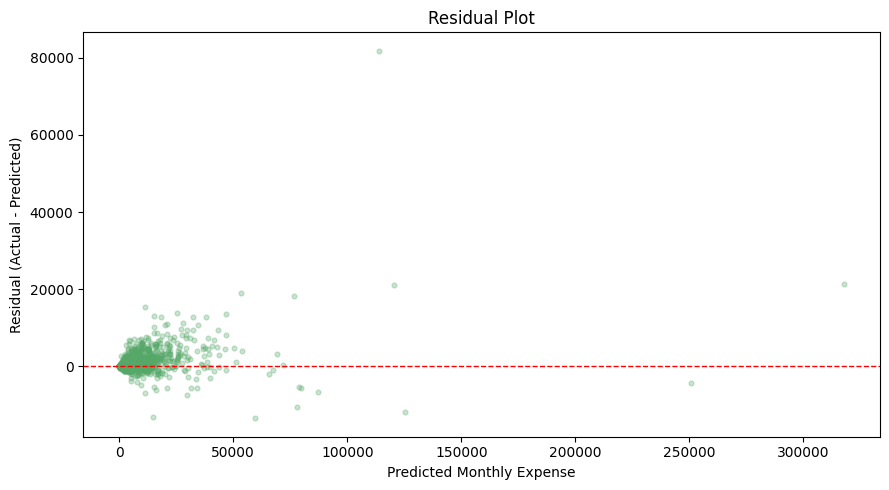

In [28]:
def plot_residuals(y_true, y_pred, sample_size=2000, random_seed=RANDOM_SEED):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    pred_arr = np.asarray(y_pred)

    if len(residuals) > sample_size:
        idx = np.random.RandomState(random_seed).choice(len(residuals), sample_size, replace=False)
        pred_arr, residuals = pred_arr[idx], residuals[idx]

    plt.figure(figsize=(9, 5))
    plt.scatter(pred_arr, residuals, alpha=0.3, s=12, color="#55A868")
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.xlabel("Predicted Monthly Expense")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title("Residual Plot")
    plt.tight_layout()
    plt.show()


plot_residuals(y_test, y_pred_test)

## 10. Save the Inference Artifact\n\nEverything `02_Demo.ipynb` needs at inference time is bundled into a single `joblib` file, including the exact ARIMA and calendar configuration used here so the demo notebook never has to hardcode or re-derive it.

In [29]:
artifact_bundle = {
    "model": rf_model,
    "encoders": encoders,
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "categorical_feature_cols": CATEGORICAL_FEATURE_COLS,
    "categories": EXPENSE_CATEGORIES,
    "base_year": BASE_YEAR,
    "arima_config": {
        "order": list(ARIMA_ORDER),
        "min_history": ARIMA_MIN_HISTORY,
        "forecast_steps": ARIMA_FORECAST_STEPS,
        "lower_band": ARIMA_LOWER_BAND,
        "upper_band": ARIMA_UPPER_BAND,
    },
    "calendar_config": {
        "event_category_map": EVENT_CATEGORY_MAP,
        "default_event_categories": DEFAULT_EVENT_CATEGORIES,
        "recurring_event_types": sorted(RECURRING_EVENT_TYPES),
        "importance_rank": IMPORTANCE_RANK,
        "importance_weight": IMPORTANCE_WEIGHT,
        "trailing_window": CALENDAR_TRAILING_WINDOW,
    },
    "split_config": {
        "test_months": TEST_MONTHS,
        "split_cutoff_time_idx": int(SPLIT_CUTOFF_TIME_IDX),
    },
    "best_rf_params": best_rf_params,
    "test_metrics": test_metrics,
    "feature_importance": feature_importance_df.to_dict(orient="records"),
}

joblib.dump(artifact_bundle, ARTIFACT_PATH)

print("=" * 60)
print("Hybrid artifact saved")
print("=" * 60)
print(f"Path            : {ARTIFACT_PATH}")
print(f"Model           : {type(rf_model).__name__}")
print(f"Features        : {len(FEATURE_COLS)}")
print(f"Encoders        : {list(encoders.keys())}")
print(f"Test MAE        : {test_metrics['mae']:.4f}")
print(f"Test R2         : {test_metrics['r2']:.4f}")

Hybrid artifact saved
Path            : .\hybrid_artifacts.pkl
Model           : RandomForestRegressor
Features        : 21
Encoders        : ['user_id', 'expense_category', 'gender', 'occupation', 'city', 'marital_status', 'financial_personality', 'upcoming_event_type', 'event_importance_level']
Test MAE        : 1163.4133
Test R2         : 0.9443
